In [ ]:
Pipeline de Pedidos de E-commerce

'''1️⃣ Contexto do Problema

Você trabalha como analista de dados em um e-commerce.

A empresa possui uma API interna que retorna pedidos realizados pelos clientes.
Cada pedido contém:

informações do pedido

informações do cliente

uma lista de produtos comprados

quantidade e preço de cada item

Seu trabalho é:

Extrair os dados da API

Transformar os dados em tabelas analíticas

Calcular métricas de vendas

Gerar visualizações simples
'''

In [ ]:
'''3️⃣ Objetivo do Pipeline

Você deverá construir um pipeline simples:

API (JSON)
     ↓
Normalização
     ↓
Tabela de pedidos
Tabela de itens
Tabela de clientes
     ↓
Cálculo de métricas
     ↓
Visualização
4️⃣ Lista de Tarefas
Parte 1 — Transformação inicial

1️⃣ Transformar o JSON em um DataFrame inicial.

Parte 2 — Normalização

Criar uma tabela de itens explodida, onde cada linha representa um item comprado.

Parte 3 — Engenharia de dados

Criar uma nova coluna:

valor_item
Parte 4 — Métricas de negócio

Calcular:

1️⃣ Faturamento total

2️⃣ Faturamento por categoria

3️⃣ Faturamento por cliente

4️⃣ Top produtos por receita

Parte 5 — Análise temporal

Converter a coluna data para datetime.

Depois calcular:

faturamento por dia

Parte 6 — Visualização

Criar pelo menos 2 gráficos com matplotlib:

1️⃣ Faturamento por categoria

2️⃣ Faturamento por dia'''

In [35]:
pedidos_api = [
    {
        "pedido_id": 1001,
        "data": "2025-01-10",
        "cliente": {
            "cliente_id": 1,
            "nome": "Ana",
            "cidade": "São Paulo"
        },
        "itens": [
            {"produto": "Notebook", "categoria": "Eletrônicos", "quantidade": 1, "preco": 3500},
            {"produto": "Mouse", "categoria": "Eletrônicos", "quantidade": 2, "preco": 80}
        ]
    },
    {
        "pedido_id": 1002,
        "data": "2025-01-11",
        "cliente": {
            "cliente_id": 2,
            "nome": "Carlos",
            "cidade": "Rio de Janeiro"
        },
        "itens": [
            {"produto": "Cadeira Gamer", "categoria": "Móveis", "quantidade": 1, "preco": 1200}
        ]
    },
    {
        "pedido_id": 1003,
        "data": "2025-01-11",
        "cliente": {
            "cliente_id": 1,
            "nome": "Ana",
            "cidade": "São Paulo"
        },
        "itens": [
            {"produto": "Teclado Mecânico", "categoria": "Eletrônicos", "quantidade": 1, "preco": 450},
            {"produto": "Mousepad", "categoria": "Acessórios", "quantidade": 1, "preco": 120}
        ]
    }
]

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

df=pd.DataFrame(pedidos_api)
print(df)

   pedido_id        data                                            cliente  \
0       1001  2025-01-10  {'cliente_id': 1, 'nome': 'Ana', 'cidade': 'Sã...   
1       1002  2025-01-11  {'cliente_id': 2, 'nome': 'Carlos', 'cidade': ...   
2       1003  2025-01-11  {'cliente_id': 1, 'nome': 'Ana', 'cidade': 'Sã...   

                                               itens  
0  [{'produto': 'Notebook', 'categoria': 'Eletrôn...  
1  [{'produto': 'Cadeira Gamer', 'categoria': 'Mó...  
2  [{'produto': 'Teclado Mecânico', 'categoria': ...  


In [37]:
df=df.explode("itens")
print(df)

   pedido_id        data                                            cliente  \
0       1001  2025-01-10  {'cliente_id': 1, 'nome': 'Ana', 'cidade': 'Sã...   
0       1001  2025-01-10  {'cliente_id': 1, 'nome': 'Ana', 'cidade': 'Sã...   
1       1002  2025-01-11  {'cliente_id': 2, 'nome': 'Carlos', 'cidade': ...   
2       1003  2025-01-11  {'cliente_id': 1, 'nome': 'Ana', 'cidade': 'Sã...   
2       1003  2025-01-11  {'cliente_id': 1, 'nome': 'Ana', 'cidade': 'Sã...   

                                               itens  
0  {'produto': 'Notebook', 'categoria': 'Eletrôni...  
0  {'produto': 'Mouse', 'categoria': 'Eletrônicos...  
1  {'produto': 'Cadeira Gamer', 'categoria': 'Móv...  
2  {'produto': 'Teclado Mecânico', 'categoria': '...  
2  {'produto': 'Mousepad', 'categoria': 'Acessóri...  


In [38]:
clientes= pd.json_normalize(df["cliente"])
print (clientes)

   cliente_id    nome          cidade
0           1     Ana       São Paulo
0           1     Ana       São Paulo
1           2  Carlos  Rio de Janeiro
2           1     Ana       São Paulo
2           1     Ana       São Paulo


In [39]:
itens=pd.json_normalize(df["itens"])
print(itens)

            produto    categoria  quantidade  preco
0          Notebook  Eletrônicos           1   3500
0             Mouse  Eletrônicos           2     80
1     Cadeira Gamer       Móveis           1   1200
2  Teclado Mecânico  Eletrônicos           1    450
2          Mousepad   Acessórios           1    120


In [40]:
df=df.drop(columns="cliente")
print(df)

   pedido_id        data                                              itens
0       1001  2025-01-10  {'produto': 'Notebook', 'categoria': 'Eletrôni...
0       1001  2025-01-10  {'produto': 'Mouse', 'categoria': 'Eletrônicos...
1       1002  2025-01-11  {'produto': 'Cadeira Gamer', 'categoria': 'Móv...
2       1003  2025-01-11  {'produto': 'Teclado Mecânico', 'categoria': '...
2       1003  2025-01-11  {'produto': 'Mousepad', 'categoria': 'Acessóri...


In [41]:
df=df.drop(columns="itens")
print(df)

   pedido_id        data
0       1001  2025-01-10
0       1001  2025-01-10
1       1002  2025-01-11
2       1003  2025-01-11
2       1003  2025-01-11


In [42]:
df=pd.concat([df,clientes,itens], axis=1)
print (df)

   pedido_id        data  cliente_id    nome          cidade  \
0       1001  2025-01-10           1     Ana       São Paulo   
0       1001  2025-01-10           1     Ana       São Paulo   
1       1002  2025-01-11           2  Carlos  Rio de Janeiro   
2       1003  2025-01-11           1     Ana       São Paulo   
2       1003  2025-01-11           1     Ana       São Paulo   

            produto    categoria  quantidade  preco  
0          Notebook  Eletrônicos           1   3500  
0             Mouse  Eletrônicos           2     80  
1     Cadeira Gamer       Móveis           1   1200  
2  Teclado Mecânico  Eletrônicos           1    450  
2          Mousepad   Acessórios           1    120  


In [43]:
df['valor_item']= df["quantidade"]*df['preco']


In [44]:
faturamento_total= df['valor_item'].sum()
print(f"faturamento_total é de  {faturamento_total} R$")


faturamento_total é de  5430 R$


In [45]:
fat_cat=df.groupby('categoria')['valor_item'].sum()
print(fat_cat)

categoria
Acessórios      120
Eletrônicos    4110
Móveis         1200
Name: valor_item, dtype: int64


In [46]:
fat_cli=df.groupby('nome')['valor_item'].sum()
print(fat_cli)

nome
Ana       4230
Carlos    1200
Name: valor_item, dtype: int64


In [47]:
top_produtos=df.groupby('produto')['valor_item'].sum().sort_values(ascending=False)
print(top_produtos)

produto
Notebook            3500
Cadeira Gamer       1200
Teclado Mecânico     450
Mouse                160
Mousepad             120
Name: valor_item, dtype: int64


In [48]:
df.info()

<class 'pandas.DataFrame'>
Index: 5 entries, 0 to 2
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   pedido_id   5 non-null      int64
 1   data        5 non-null      str  
 2   cliente_id  5 non-null      int64
 3   nome        5 non-null      str  
 4   cidade      5 non-null      str  
 5   produto     5 non-null      str  
 6   categoria   5 non-null      str  
 7   quantidade  5 non-null      int64
 8   preco       5 non-null      int64
 9   valor_item  5 non-null      int64
dtypes: int64(5), str(5)
memory usage: 668.0 bytes


In [50]:
df['date']=pd.to_datetime(df['data'])
df.info()

<class 'pandas.DataFrame'>
Index: 5 entries, 0 to 2
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   pedido_id   5 non-null      int64         
 1   data        5 non-null      str           
 2   cliente_id  5 non-null      int64         
 3   nome        5 non-null      str           
 4   cidade      5 non-null      str           
 5   produto     5 non-null      str           
 6   categoria   5 non-null      str           
 7   quantidade  5 non-null      int64         
 8   preco       5 non-null      int64         
 9   valor_item  5 non-null      int64         
 10  date        5 non-null      datetime64[us]
dtypes: datetime64[us](1), int64(5), str(5)
memory usage: 708.0 bytes


In [67]:
faturamento_por_dia=df.groupby('date')['valor_item'].sum()
print(faturamento_por_dia)

date
2025-01-10    3660
2025-01-11    1770
Name: valor_item, dtype: int64


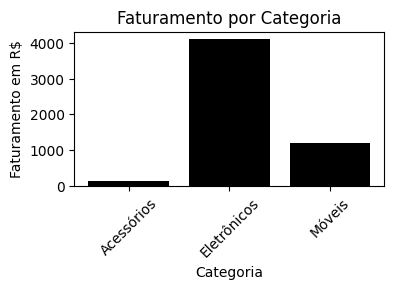

In [65]:
plt.figure(figsize=(4,2))
plt.bar(fat_cat.index, fat_cat.values, color='black')
plt.title('Faturamento por Categoria')
plt.xlabel('Categoria')
plt.ylabel('Faturamento em R$')
plt.xticks(rotation=45)
plt.show()

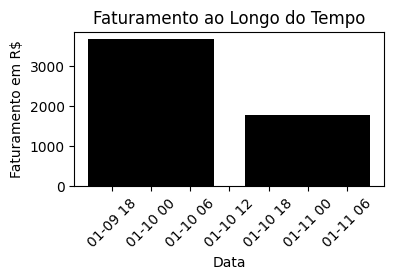

In [68]:
plt.figure(figsize=(4,2))
plt.bar(faturamento_por_dia.index,
        faturamento_por_dia.values, color='black')
plt.title('Faturamento ao Longo do Tempo')
plt.xlabel('Data')
plt.ylabel('Faturamento em R$')
plt.xticks(rotation=45)
plt.show()